# Project links

**Github repository**
https://github.com/phkhle/IND320

**Streamlitt app**
https://ind320-h2026.streamlit.app/



# Resevoir dataset

## Import libraries

In [76]:
import pandas as pd
import matplotlib.pyplot as plt

## Read in file

In [72]:
df = pd.read_csv('reservoirs.csv')
df

,dato_Id,omrType,omrnr,iso_aar,iso_uke,fyllingsgrad,kapasitet_TWh,fylling_TWh,neste_Publiseringsdato,fyllingsgrad_forrige_uke,endring_fyllingsgrad
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301
...,...,...,...,...,...,...,...,...,...,...,...
14872,2026-07-19,VASS,3,2026,29,0.796849,28.155403,22.435612,2026-07-29T13:00:00,0.794957,0.001892
14873,2026-09-06,VASS,3,2026,36,0.826252,28.155403,23.263466,2026-09-16T13:00:00,0.827641,-0.001389
14874,2026-08-30,VASS,3,2026,35,0.827718,28.155403,23.304743,2026-09-09T13:00:00,0.829898,-0.002180
14875,2026-09-06,VASS,1,2026,36,0.570397,36.044464,20.559645,2026-09-16T13:00:00,0.567087,0.003310


## Data analysis

Rename headers to English and understandable.


In [73]:
df = df.rename(columns={
    "dato_Id": "date_Id",
    "omrType": "areaType",
    "omrnr" : "areaNr",	
    "iso_aar": "year",	
    "iso_uke": "week",	
    "fyllingsgrad": "filling_level",	
    "kapasitet_TWh": "capacity_TWh",
    "fylling_TWh": "filling_TWh",
    "neste_Publiseringsdato": "next_publication_date",
    "fyllingsgrad_forrige_uke": "filling_level_last_week",
    "endring_fyllingsgrad": "change_filling_level"
})

In [ ]:
df

,date_Id,areaType,areaNr,year,week,filling_level,capacity_TWh,filling_TWh,next_publication_date,filling_level_last_week,change_filling_level
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301
...,...,...,...,...,...,...,...,...,...,...,...
14872,2026-07-19,VASS,3,2026,29,0.796849,28.155403,22.435612,2026-07-29T13:00:00,0.794957,0.001892
14873,2026-09-06,VASS,3,2026,36,0.826252,28.155403,23.263466,2026-09-16T13:00:00,0.827641,-0.001389
14874,2026-08-30,VASS,3,2026,35,0.827718,28.155403,23.304743,2026-09-09T13:00:00,0.829898,-0.002180
14875,2026-09-06,VASS,1,2026,36,0.570397,36.044464,20.559645,2026-09-16T13:00:00,0.567087,0.003310


In [75]:
# Show all columns and their data types
print(df.dtypes)
# Change "date_Id" and "next_publication_date" to datetime format
df['date_Id'] = pd.to_datetime(df['date_Id'])
df['next_publication_date'] = pd.to_datetime(df['next_publication_date'], errors='coerce')

date_Id                     object
areaType                    object
areaNr                       int64
year                         int64
week                         int64
filling_level              float64
capacity_TWh               float64
filling_TWh                float64
next_publication_date       object
filling_level_last_week    float64
change_filling_level       float64
dtype: object


C:\Users\khanh\AppData\Local\Temp\ipykernel_12068\2747876171.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['next_publication_date'] = pd.to_datetime(df['next_publication_date'], errors='coerce')


Plot each column separately


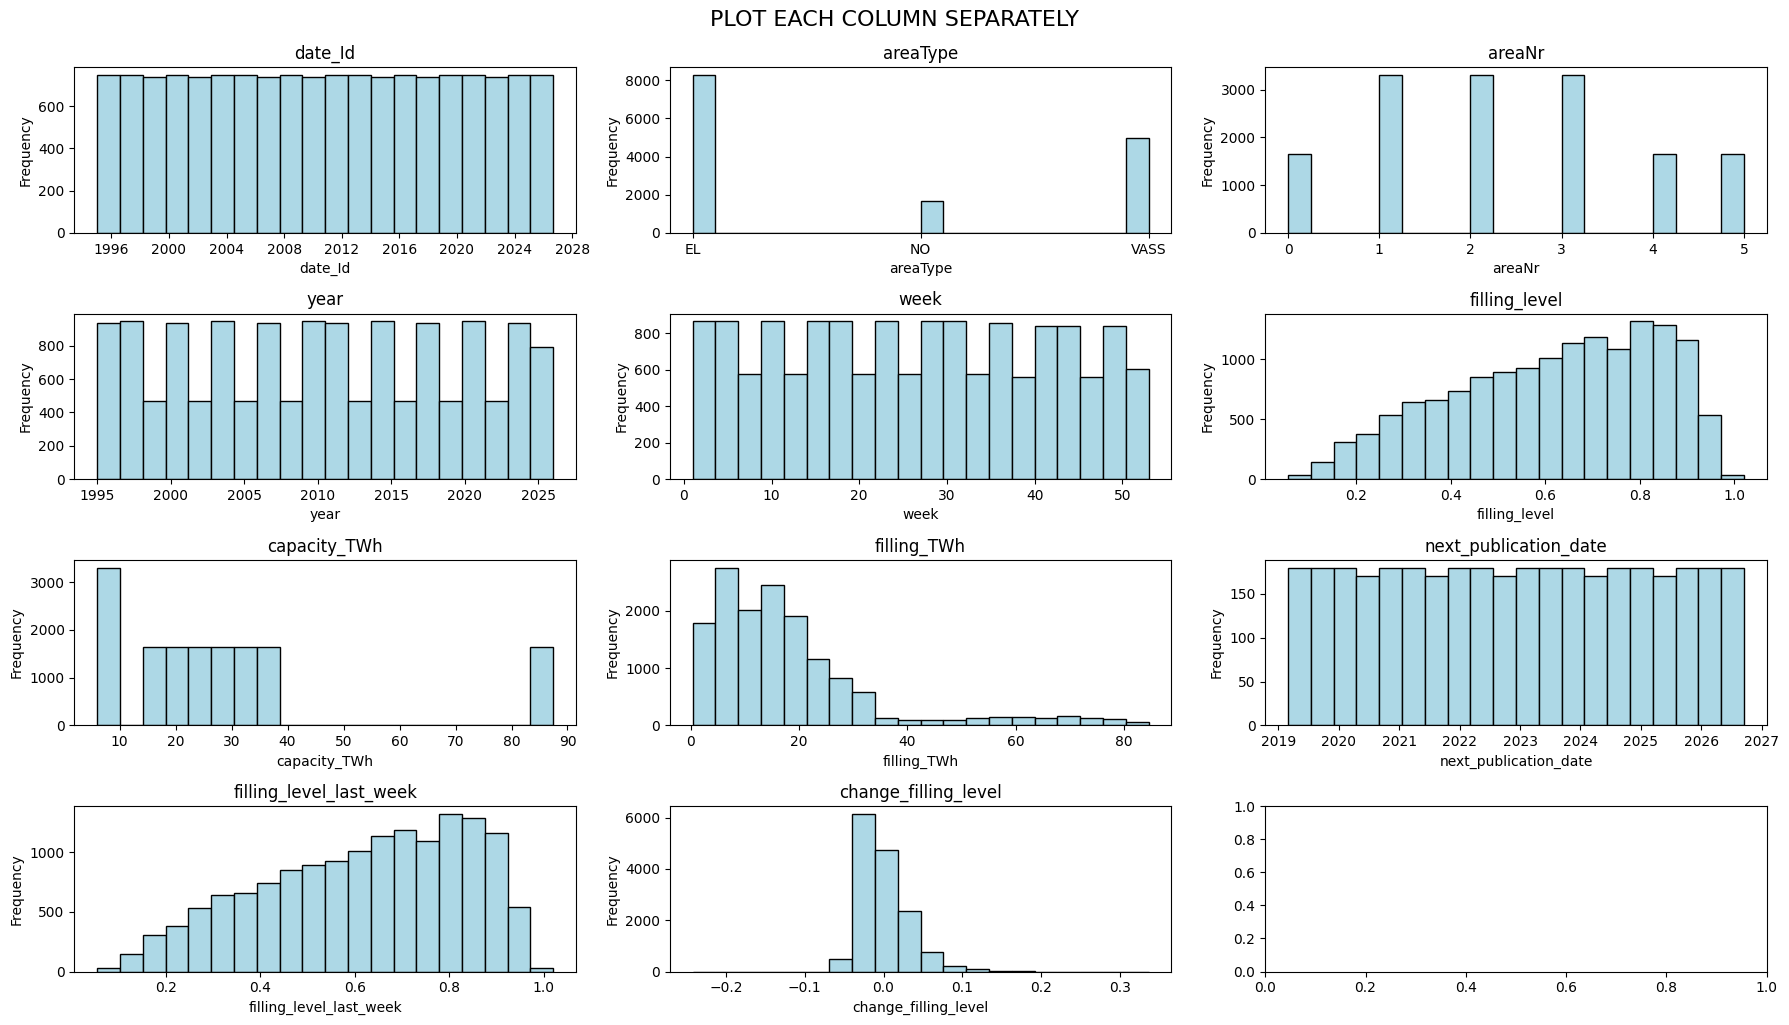

In [84]:
# create a figure and axes using subplots
fig, axes = plt.subplots(nrows = 4, ncols = 3, figsize = (18, 10))
# since ax is an array, we flatten it to plot the histogram
axes = axes.flatten()
for i, fea in enumerate(df.columns):
    ax = axes[i] # Select current axis
    ax.hist(df[fea], bins = 20, color = 'lightblue', edgecolor = 'black')
    ax.set_xlabel(fea)
    ax.set_ylabel('Frequency')
    ax.set_title(f'{fea}')
# adjust layout to prevent overlap of subplots
plt.tight_layout()
# Add a main title to the figure
plt.suptitle('PLOT EACH COLUMN SEPARATELY', fontsize = 16, y = 1.02)
plt.show()